# Dubai NW Road map

### Import and load files

In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

col = ["EQT_NO", "EQT_EXT_ID", "ROAD_NAME", "LONGITUDE", "LATITUDE", "LINK_ID"]
df = pd.read_excel("C:/Users/danie/Documents/internship/KG-road/iTraffic-VMS-List.xlsx", usecols = col)
gdf = gpd.read_file("C:/Users/danie/Documents/internship/KG-road/map_nw_road_dubai_new1 (1)/map_nw_road_dubai_new1.shp")

In [ ]:
print(gdf.head())
print(gdf.crs)
gdf.plot()

In [221]:
print(gdf.columns)


Index(['no', 'id', 'feattyp', 'ft', 'f_jnctid', 'f_jncttyp', 't_jnctid',
       't_jncttyp', 'pj', 'meters', 'frc', 'netclass', 'netbclass',
       'net2class', 'name', 'namelc', 'sol', 'nametyp', 'charge', 'shieldnum',
       'rtetyp', 'rtedir', 'rtedirvd', 'procstat', 'fow', 'sliprd', 'freeway',
       'backrd', 'tollrd', 'rdcond', 'stubble', 'privaterd', 'constatus',
       'oneway', 'f_bp', 't_bp', 'f_elev', 't_elev', 'kph', 'minutes',
       'posaccur', 'carriage', 'lanes', 'ramp', 'ada', 'trans', 'dynspeed',
       'speedcat', 'nthrutraf', 'roughrd', 'partstruc', 'order01',
       'roadclassi', 'geometry'],
      dtype='object')
0         1.784001e+13
1         1.784001e+13
2         1.784001e+13
3         1.784001e+13
4         1.784001e+13
              ...     
236559    1.784001e+13
236560    1.784001e+13
236561    1.784001e+13
236562    1.784001e+13
236563    1.784001e+13
Name: f_jnctid, Length: 236564, dtype: float64


### Adding VMS locations

In [ ]:

eqt_df = pd.DataFrame(df)
u_col = ["end_x_coor", "end_y_coor"]
e_df = pd.read_csv("C:/Users/danie/Documents/internship/KG-road/dubai_data/emr.csv", usecols = u_col)
e_xy_df = pd.DataFrame(e_df)

minx, miny, maxx, maxy = gdf.total_bounds

filtered_e_xy_df = e_xy_df.loc[
    (e_xy_df['end_x_coor'] >= minx) &
    (e_xy_df['end_x_coor'] <= maxx) &
    (e_xy_df['end_y_coor'] >= miny) &
    (e_xy_df['end_y_coor'] <= maxy)
]

geometry_xy = [Point(xy) for xy in zip(filtered_e_xy_df['end_x_coor'], filtered_e_xy_df['end_y_coor'])]
geometry = [Point(xy) for xy in zip(eqt_df['LONGITUDE'], eqt_df['LATITUDE'])]

equipment_gdf = gpd.GeoDataFrame(
    eqt_df,
    geometry=geometry,
    crs=gdf.crs 
)

event_gdf = gpd.GeoDataFrame(
    filtered_e_xy_df,
    geometry=geometry_xy,
    crs=gdf.crs 
)

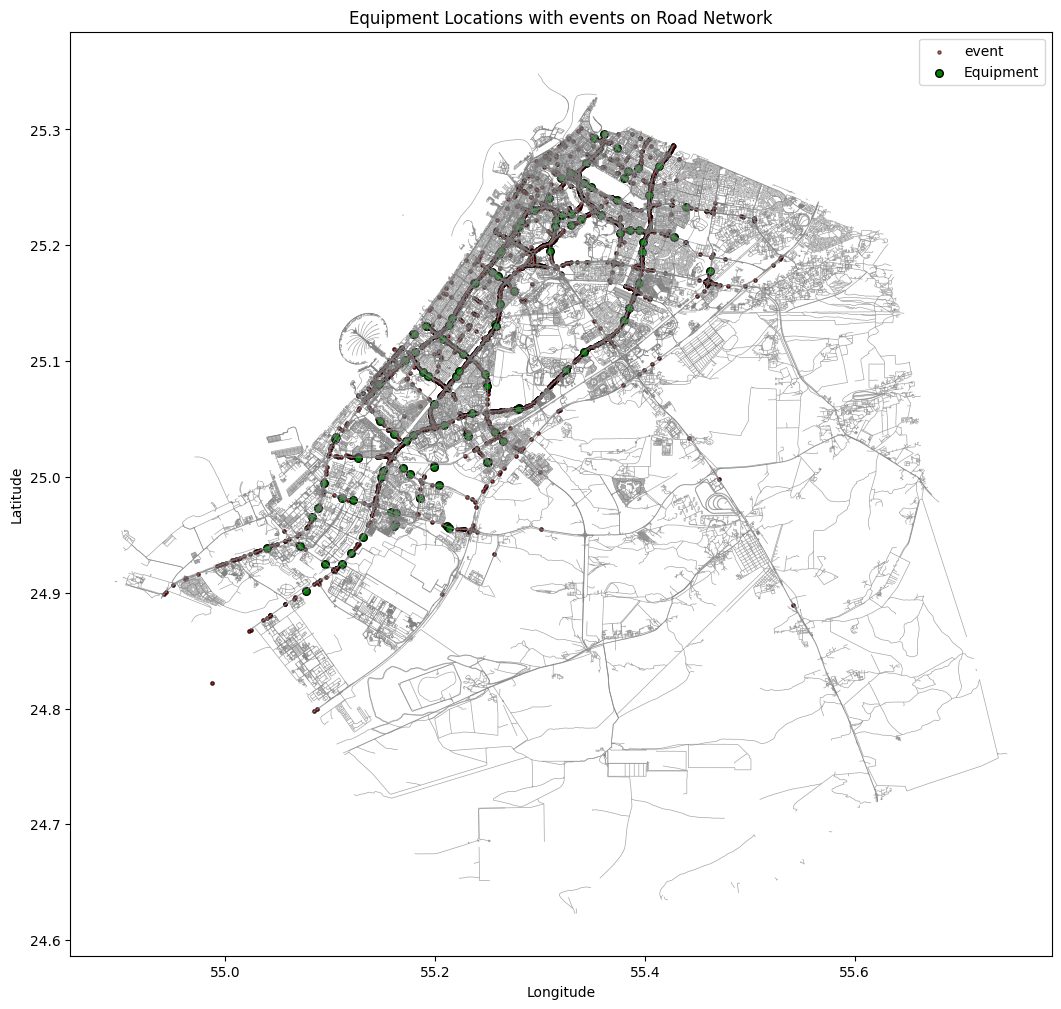

In [90]:
fig, ax = plt.subplots(figsize=(15, 12))

gdf.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.7)

event_gdf.plot(
    ax=ax,
    color='red',
    markersize=5,
    alpha= 0.6,
    edgecolor='black',
    label='event'
)

equipment_gdf.plot(
    ax=ax,
    color='green',
    markersize=30,
    edgecolor='black',
    label='Equipment'
)

plt.title("Equipment Locations with events on Road Network")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.savefig('road_network_with_equipment.png', dpi=300, bbox_inches='tight')
plt.show()

### analyzing Dubai data

In [4]:
emr = pd.read_csv("C:/Users/danie/Documents/internship/KG-road/dubai_data/emr.csv", low_memory=False)
emp = pd.read_csv("C:/Users/danie/Documents/internship/KG-road/dubai_data/emp.csv")
empc = pd.read_csv("C:/Users/danie/Documents/internship/KG-road/dubai_data/empc.csv")
emep = pd.read_csv("C:/Users/danie/Documents/internship/KG-road/dubai_data/emep.csv")
vms_df = pd.read_excel("C:/Users/danie/Documents/internship/KG-road/iTraffic-VMS-List.xlsx")
emr_df = pd.DataFrame(emr)
emp_df = pd.DataFrame(emp)
empc_df = pd.DataFrame(empc)



### Filtering of the data

Matching EMR to EMP
creates EMP Filtered from EMR

In [6]:
common_id = set(emr_df["id"].values) & set(emp["event_id"].values)
emr_df_f = emr_df[emr_df["id"].isin(common_id)]
emp_df_from_emr = emp_df[emp_df["event_id"].isin(common_id)]
# emr_df_f.to_csv("emr_df_f.csv", index = False)
# emp_df_from_emr.to_csv("emp_df_from_emr.csv", index = False)

cleaning the empc df

In [ ]:
empc_df_dms = empc_df[empc_df["sys_id"] == "DMS"].reset_index(drop=True)
empc_df_dms = empc_df_dms[(empc_df_dms["cmd_status"] == "MA") | (empc_df_dms["cmd_status"] == "OA")].reset_index(drop=True)
c_id = set(empc_df_dms["eqt_site_id"].values) & set(vms_df["EQT_EXT_ID"].values)
empc_df_dms = empc_df_dms[empc_df_dms["eqt_site_id"].isin(c_id)]

Filtering VMS data

In [ ]:
vms_df.to_csv("vms_df_final.csv", index = False)

Matching EMP to EMPC

In [ ]:

common_id2 = set(emp_df_from_emr["id"].values) & set(empc_df_dms["plan_id"].values)
emp_df_from_empc = emp_df_from_emr[emp_df_from_emr["id"].isin(common_id2)]
empc_df_from_emp = empc_df_dms[empc_df_dms["plan_id"].isin(common_id2)]
empc_df_from_emp.to_csv("empc_df_final.csv", index = False)

Run the matching for emp and emr again

In [ ]:
common_id3 = set(emr_df_f["id"].values) & set(emp_df_from_empc["event_id"].values)
emr_df_final = emr_df_f[emr_df_f["id"].isin(common_id3)]
emp_df_final= emp_df_from_empc[emp_df_from_empc["event_id"].isin(common_id3)]
emr_df_final.to_csv("emr_df_final.csv", index = False)
emp_df_final.to_csv("emp_df_final.csv", index = False)

row count

In [ ]:
print(emr_df_final["id"].drop_duplicates().count(), "unique event records")
print(emr_df_final["id"].count(), "event records")
print(emp_df_final["id"].count(), "event plans")
print(empc_df_from_emp["id"].count(), "event plan records")
print(vms_df_final["EQT_NO"].count(), " VMS equipments used")

22 unique event records
44 event records
87 event plans
227 event plan records
21  VMS equipments used


In [ ]:
import json

In [ ]:
raw_json = """
[
  {
    "keys": [
      "e.id",
      "e.event_no"
    ],
    "length": 2,
    "_fields": [
      {
        "low": 526470,
        "high": 0
      },
      "20240902/0004"
    ],
    "_fieldLookup": {
      "e.id": 0,
      "e.event_no": 1
    }
  }
]
"""
data = json.loads(raw_json.strip())
print(data)

[{'keys': ['e.id', 'e.event_no'], 'length': 2, '_fields': [{'low': 526470, 'high': 0}, '20240902/0004'], '_fieldLookup': {'e.id': 0, 'e.event_no': 1}}]
